CS 282 (Computer Vision) <br>
Programming Assignment 3 <br>
Epipolar Geometry <br>

Professor: Dr. Prospero C. Naval Jr. <br>
Student: Deomary Angelo B. Franco, 202322049 <br>


This notebook estimates the fundamental matrix and performs linear least-squares triangulation on the `library1` / `library2` image pair, following the five-step assignment specification.

The structure mirrors `PA2-Image_Stitching/pa2-image_stitching.ipynb`: one `#` H1 header per step, a short intro, the implementation with logging, and one or more visualization cells. Each step's residual is captured in a live variable so the **Summary of Residuals** at the bottom recomputes automatically when any upstream cell is edited and re-run.

# PARAMETERS

In [1]:
import logging
import os
import platform

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR     = "epipairs"
IMG1_PATH    = os.path.join(DATA_DIR, "library1.jpg")
IMG2_PATH    = os.path.join(DATA_DIR, "library2.jpg")
MATCHES_PATH = os.path.join(DATA_DIR, "library_matches.txt")
CAM1_PATH    = os.path.join(DATA_DIR, "library1_camera.txt")
CAM2_PATH    = os.path.join(DATA_DIR, "library2_camera.txt")

# ---------------------------------------------------------------------------
# Step 3 — Harris detector + patch descriptor + Lowe ratio test
# ---------------------------------------------------------------------------
HARRIS_BLOCK_SIZE   = 3
HARRIS_KSIZE        = 3
HARRIS_K            = 0.04
HARRIS_RESP_PCTILE  = 99.0   # keep keypoints whose response exceeds this percentile
HARRIS_NMS_RADIUS   = 5      # non-max-suppression radius (pixels)
PATCH_SIZE          = 41
LOWE_RATIO          = 0.85   # Lowe ratio threshold — primary defense vs. repeating windows
CROSS_CHECK         = True   # require mutual nearest neighbour as well

# ---------------------------------------------------------------------------
# Step 3 — RANSAC for normalized 8-point F
# ---------------------------------------------------------------------------
RANSAC_ITERS       = 10_000
RANSAC_THRESH_PX   = 1.     # Sampson distance inlier threshold
RNG_SEED           = 42

# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
N_LINES_VIZ        = 25      # number of epipolar lines / matches to draw in samples
RAY_STRIDE         = 15      # plot 1-of-N back-projection rays in the 3D figure
IMG_PLANE_STRIDE   = 14      # texture-mesh stride (smaller = sharper, larger HTML)

# ---------------------------------------------------------------------------
# Logging banner
# ---------------------------------------------------------------------------
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
logging.info("Python   : %s", platform.python_version())
logging.info("NumPy    : %s", np.__version__)
logging.info("OpenCV   : %s", cv2.__version__)
logging.info("Pandas   : %s", pd.__version__)
logging.info("Platform : %s %s", platform.system(), platform.release())

np.random.seed(RNG_SEED)


Python   : 3.12.12
NumPy    : 2.4.1
OpenCV   : 4.11.0
Pandas   : 3.0.0
Platform : Darwin 25.3.0


# Step 1: Load Image Pair, Camera Matrices, and Ground-Truth Matches

Load the two library images, the 309 ground-truth matches in `library_matches.txt`, and the two 3×4 projection matrices `library{1,2}_camera.txt`. Images are kept in two parallel forms — float64 RGB in [0, 1] for matplotlib display, and float64 grayscale in [0, 1] for processing — matching the convention used in PA2.

In [2]:
def load_image(path):
    """Load an image as (RGB float64 in [0,1], grayscale float64 in [0,1])."""
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
    return rgb, gray


img1_rgb, img1_gray = load_image(IMG1_PATH)
img2_rgb, img2_gray = load_image(IMG2_PATH)

# library_matches.txt: each row is "x1 y1 x2 y2"
gt_matches = np.loadtxt(MATCHES_PATH)
pts1_gt = gt_matches[:, :2].astype(np.float64)   # (N, 2)
pts2_gt = gt_matches[:, 2:].astype(np.float64)   # (N, 2)

# Camera projection matrices, 3x4 each
P1 = np.loadtxt(CAM1_PATH)
P2 = np.loadtxt(CAM2_PATH)
assert P1.shape == (3, 4) and P2.shape == (3, 4)

logging.info("Image 1     : %s  shape=%s", IMG1_PATH, img1_rgb.shape)
logging.info("Image 2     : %s  shape=%s", IMG2_PATH, img2_rgb.shape)
logging.info("GT matches  : %d correspondences", len(gt_matches))
logging.info("P1 =\n%s", P1)
logging.info("P2 =\n%s", P2)


Image 1     : epipairs/library1.jpg  shape=(384, 512, 3)
Image 2     : epipairs/library2.jpg  shape=(384, 512, 3)
GT matches  : 309 correspondences
P1 =
[[-4.5250208e+01  4.8215478e+02  4.0948922e+02  3.4440464e+03]
 [ 4.8858466e+02  2.7346374e+02 -1.3977268e+02  4.8030231e+03]
 [-1.9787463e-01  8.8042214e-01 -4.3093212e-01  2.8032556e+01]]
P2 =
[[-5.9593834e+01  5.5643970e+02  2.3093716e+02  3.5683545e+03]
 [ 4.6419679e+02  2.2628430e+02 -1.9605278e+02  4.8734171e+03]
 [-1.9116708e-01  7.2057697e-01 -6.6650130e-01  2.8015392e+01]]


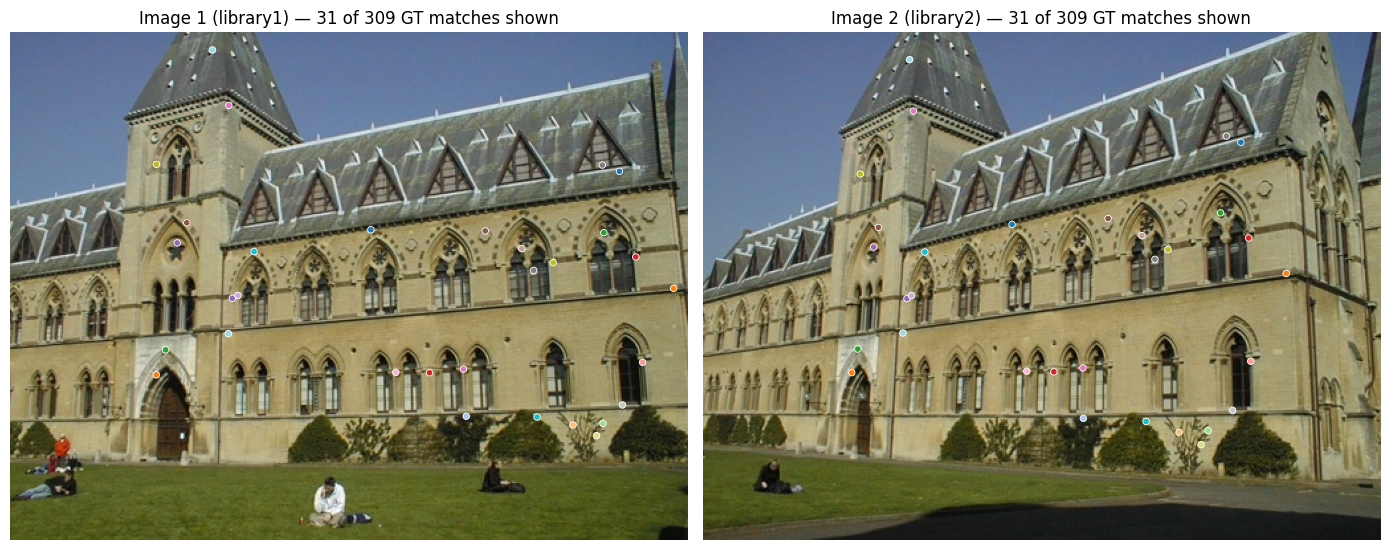

In [3]:
# Visualise: side-by-side images with a sampled subset of GT matches drawn
# in colour-consistent dots so the same colour = same correspondence in both views.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sample_idx = np.arange(0, len(pts1_gt), 10)
colors = plt.cm.tab20(np.linspace(0, 1, len(sample_idx)))

for ax, img, pts, title in [
    (axes[0], img1_rgb, pts1_gt, "Image 1 (library1)"),
    (axes[1], img2_rgb, pts2_gt, "Image 2 (library2)"),
]:
    ax.imshow(img)
    ax.scatter(pts[sample_idx, 0], pts[sample_idx, 1],
               c=colors, s=22, edgecolors="white", linewidths=0.6)
    ax.set_title(f"{title} — {len(sample_idx)} of {len(pts)} GT matches shown")
    ax.set_axis_off()

plt.tight_layout()
plt.show()


# Step 2: Fit Fundamental Matrix to Ground-Truth Matches (Normalized 8-Point)

Estimate **F** from the 309 ground-truth matches using the **normalized 8-point algorithm** (Hartley 1995). Because all matches are correct, no RANSAC is needed.

Algorithm:
1. Translate each point set so its centroid is at the origin and isotropically scale so the mean distance from origin is √2 — encoded in similarity matrices `T1`, `T2`.
2. Build the 9-column constraint matrix **A** from `(p1ᵀ p2ᵀ 1)` cross-terms; the right null vector of **A** (smallest right-singular vector) reshapes into `F̂`.
3. Enforce `det(F) = 0` by zeroing the smallest singular value of `F̂`.
4. Denormalize: `F = T2ᵀ · F_rank2 · T1`.

The reported residual is the spec's quantity — **mean squared distance (in pixels) between points in image 2 and the corresponding epipolar lines `l₂ = F · p₁`**.

In [4]:
def normalize_points(pts):
    """Hartley normalization: centroid -> origin, mean distance -> sqrt(2).

    Returns (pts_norm (N,2), T (3,3)) such that for homogeneous p_h,
    p_norm_h = T @ p_h.
    """
    centroid = pts.mean(axis=0)
    centered = pts - centroid
    mean_dist = np.sqrt((centered ** 2).sum(axis=1)).mean()
    if mean_dist < 1e-12:
        scale = 1.0
    else:
        scale = np.sqrt(2.0) / mean_dist
    T = np.array([[scale, 0,    -scale * centroid[0]],
                  [0,    scale, -scale * centroid[1]],
                  [0,    0,     1.0]])
    pts_norm = (T @ np.hstack([pts, np.ones((len(pts), 1))]).T).T[:, :2]
    return pts_norm, T


def estimate_F_normalized_8pt(pts1, pts2):
    """Normalized 8-point fundamental matrix estimation.

    pts1, pts2: (N, 2) arrays with N >= 8 corresponding image points.
    Returns the 3x3 fundamental matrix F satisfying p2^T F p1 = 0.
    """
    assert len(pts1) == len(pts2) >= 8

    p1n, T1 = normalize_points(pts1)
    p2n, T2 = normalize_points(pts2)

    # Build constraint matrix: each row is
    # [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1]
    x1, y1 = p1n[:, 0], p1n[:, 1]
    x2, y2 = p2n[:, 0], p2n[:, 1]
    A = np.column_stack([
        x2 * x1, x2 * y1, x2,
        y2 * x1, y2 * y1, y2,
        x1,      y1,      np.ones_like(x1),
    ])

    # F_hat is the right-singular vector of A with the smallest singular value
    _, _, Vt = np.linalg.svd(A)
    F_hat = Vt[-1].reshape(3, 3)

    # Enforce rank 2 by zeroing the smallest singular value
    Uf, Sf, Vtf = np.linalg.svd(F_hat)
    Sf[-1] = 0.0
    F_rank2 = Uf @ np.diag(Sf) @ Vtf

    # Denormalize: p2^T (T2^T F T1) p1 = 0
    F = T2.T @ F_rank2 @ T1
    F /= F[2, 2] if abs(F[2, 2]) > 1e-12 else np.linalg.norm(F)
    return F


def epipolar_distances_img2(F, pts1, pts2):
    """Per-point squared distance from p2 to its epipolar line F p1 (in pixels^2)."""
    p1_h = np.hstack([pts1, np.ones((len(pts1), 1))])
    p2_h = np.hstack([pts2, np.ones((len(pts2), 1))])
    lines2 = (F @ p1_h.T).T                   # (N, 3) — epipolar lines in image 2
    num = (lines2 * p2_h).sum(axis=1) ** 2
    den = lines2[:, 0] ** 2 + lines2[:, 1] ** 2
    return num / np.maximum(den, 1e-12)


def epipolar_residual_img2(F, pts1, pts2):
    """Mean squared point-to-line distance in image 2 (pixels^2)."""
    return float(epipolar_distances_img2(F, pts1, pts2).mean())


def sampson_distance(F, pts1, pts2):
    """Symmetric Sampson distance — used as the RANSAC inlier metric in Step 3."""
    p1_h = np.hstack([pts1, np.ones((len(pts1), 1))])
    p2_h = np.hstack([pts2, np.ones((len(pts2), 1))])
    Fp1 = (F @ p1_h.T).T          # epipolar lines in img 2
    FtP2 = (F.T @ p2_h.T).T       # epipolar lines in img 1
    num = (np.einsum("ij,ij->i", p2_h, Fp1)) ** 2
    den = Fp1[:, 0] ** 2 + Fp1[:, 1] ** 2 + FtP2[:, 0] ** 2 + FtP2[:, 1] ** 2
    return num / np.maximum(den, 1e-12)


In [5]:
F_gt = estimate_F_normalized_8pt(pts1_gt, pts2_gt)
residual_step2 = epipolar_residual_img2(F_gt, pts1_gt, pts2_gt)

logging.info("F (GT, normalized 8-pt) =\n%s", F_gt)
logging.info("Step 2 residual (mean sq. dist. img2 epipolar lines): %.6f px^2",
             residual_step2)


F (GT, normalized 8-pt) =
[[ 1.71102221e-07 -3.64735692e-06  5.51938723e-04]
 [ 2.21411651e-05  2.27537931e-07 -4.11109757e-02]
 [-5.28444344e-03  3.69220124e-02  1.00000000e+00]]
Step 2 residual (mean sq. dist. img2 epipolar lines): 0.060252 px^2


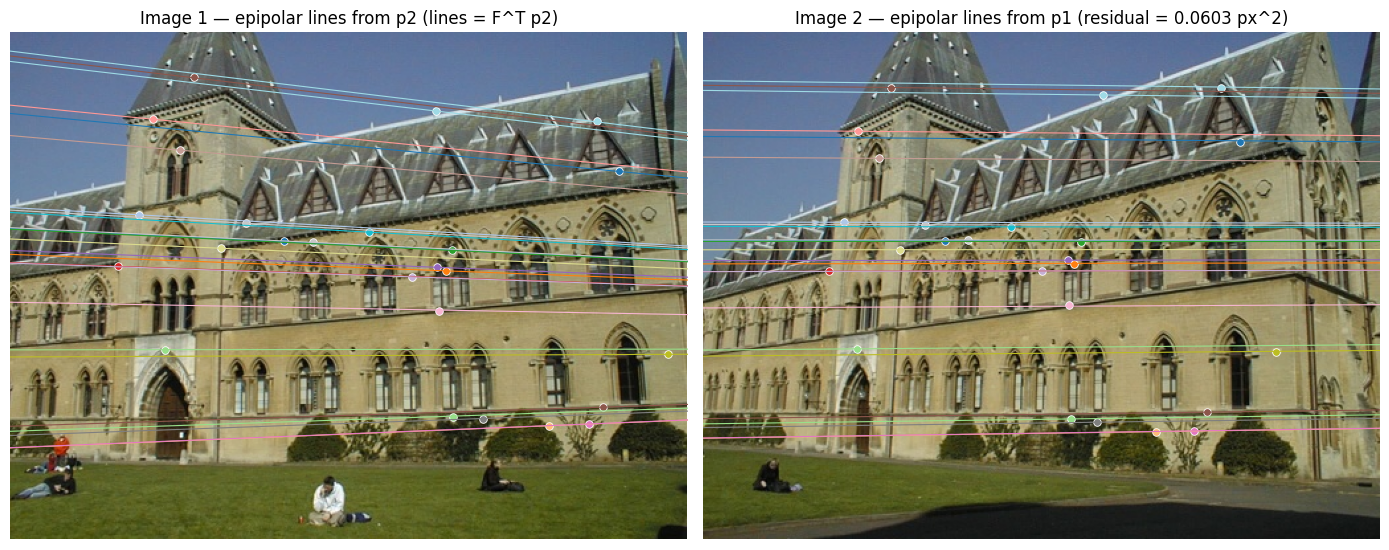

In [6]:
def draw_epipolar_lines(ax, img, lines, pts, sample_idx, title):
    """Draw a sampled subset of epipolar lines and the corresponding points."""
    h, w = img.shape[:2]
    ax.imshow(img)
    colors = plt.cm.tab20(np.linspace(0, 1, len(sample_idx)))
    for color, i in zip(colors, sample_idx):
        a, b, c = lines[i]
        # Line: a x + b y + c = 0 -> draw between x = 0 and x = w
        if abs(b) > 1e-9:
            x0, x1 = 0, w
            y0 = -(a * x0 + c) / b
            y1 = -(a * x1 + c) / b
        else:
            x0 = x1 = -c / a
            y0, y1 = 0, h
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=0.8)
        ax.scatter([pts[i, 0]], [pts[i, 1]], color=color, s=30,
                   edgecolors="white", linewidths=0.6)
    ax.set_xlim(0, w); ax.set_ylim(h, 0)
    ax.set_title(title); ax.set_axis_off()


# Lines in image 2 are F @ p1; lines in image 1 are F.T @ p2.
p1_h = np.hstack([pts1_gt, np.ones((len(pts1_gt), 1))])
p2_h = np.hstack([pts2_gt, np.ones((len(pts2_gt), 1))])
lines2 = (F_gt @ p1_h.T).T
lines1 = (F_gt.T @ p2_h.T).T

sample_idx = np.linspace(0, len(pts1_gt) - 1, N_LINES_VIZ).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_epipolar_lines(axes[0], img1_rgb, lines1, pts1_gt, sample_idx,
                    "Image 1 — epipolar lines from p2 (lines = F^T p2)")
draw_epipolar_lines(axes[1], img2_rgb, lines2, pts2_gt, sample_idx,
                    f"Image 2 — epipolar lines from p1 (residual = {residual_step2:.4f} px^2)")
plt.tight_layout()
plt.show()


# Step 3: Fit Fundamental Matrix to PA2-Style Putative Matches with RANSAC

Reproduce PA2's putative-match pipeline (Harris corners + 31×31 patch descriptors + vectorized pairwise distances) but **replace the top-N flat sort with Lowe's ratio test plus mutual nearest-neighbour cross-check**. This is the key fix for the library facade: the PA2 approach matched many false correspondences because nearby windows produced near-identical patches; the ratio test rejects exactly those ambiguous matches by demanding that the best match be substantially closer than the second-best.

Then estimate **F** with **RANSAC + normalized 8-point** (the spec mandates *only* the normalized fitting approach for this step). Inlier metric is the Sampson distance with a 1-pixel threshold. The reported residual is the same as Step 2 (mean point-to-epipolar-line squared distance in image 2), but evaluated only on the inliers.

In [7]:
def harris_keypoints(gray, block_size=HARRIS_BLOCK_SIZE, ksize=HARRIS_KSIZE,
                     k=HARRIS_K, percentile=HARRIS_RESP_PCTILE,
                     nms_radius=HARRIS_NMS_RADIUS):
    """Run Harris corner detection, threshold by percentile, then non-max suppress.

    Returns (M, 2) array of (x, y) keypoint coordinates.
    """
    gray32 = gray.astype(np.float32)
    response = cv2.cornerHarris(gray32, block_size, ksize, k)
    thresh = np.percentile(response, percentile)
    mask = response > thresh

    # Local-maximum NMS via dilation
    kernel = np.ones((2 * nms_radius + 1, 2 * nms_radius + 1), dtype=np.uint8)
    local_max = cv2.dilate(response, kernel) == response
    keep = mask & local_max
    ys, xs = np.where(keep)
    return np.column_stack([xs, ys]).astype(np.float64)


def extract_patch_descriptors(gray, kps, patch=PATCH_SIZE):
    """Extract zero-mean unit-variance flattened patches around each keypoint.

    Drops keypoints too close to the border. Returns (descriptors, kept_kps).
    """
    half = patch // 2
    h, w = gray.shape
    inside = ((kps[:, 0] >= half) & (kps[:, 0] < w - half) &
              (kps[:, 1] >= half) & (kps[:, 1] < h - half))
    kps_in = kps[inside].astype(int)
    descs = np.empty((len(kps_in), patch * patch), dtype=np.float64)
    for i, (x, y) in enumerate(kps_in):
        patch_arr = gray[y - half:y + half + 1, x - half:x + half + 1]
        flat = patch_arr.reshape(-1)
        flat = flat - flat.mean()
        norm = np.linalg.norm(flat)
        if norm > 1e-12:
            flat = flat / norm
        descs[i] = flat
    return descs, kps[inside]


def pairwise_sq_dist(A, B):
    """Vectorised squared Euclidean distance matrix: D[i,j] = ||A[i] - B[j]||^2."""
    aa = (A * A).sum(axis=1, keepdims=True)
    bb = (B * B).sum(axis=1, keepdims=True).T
    return np.maximum(aa + bb - 2.0 * A @ B.T, 0.0)


def lowe_ratio_match(D, ratio=LOWE_RATIO, cross_check=CROSS_CHECK):
    """Match descriptor row to descriptor col via Lowe ratio test (+ optional cross-check).

    Returns int array (M, 2) of (i_in_A, j_in_B) indices.
    """
    # Image 1 -> Image 2
    nn = np.argsort(D, axis=1)[:, :2]
    d_best = D[np.arange(len(D)), nn[:, 0]]
    d_2nd  = D[np.arange(len(D)), nn[:, 1]]
    pass_12 = d_best < (ratio ** 2) * d_2nd       # ratio applied to *squared* distances
    matches = np.column_stack([np.arange(len(D))[pass_12], nn[pass_12, 0]])

    if cross_check and len(matches):
        nn_back = np.argmin(D, axis=0)            # for each j in B, nearest i in A
        keep = nn_back[matches[:, 1]] == matches[:, 0]
        matches = matches[keep]
    return matches


# ---------------------------------------------------------------------------
# Detect, describe, match
# ---------------------------------------------------------------------------
kp1 = harris_keypoints(img1_gray)
kp2 = harris_keypoints(img2_gray)
logging.info("Harris keypoints  : img1=%d  img2=%d", len(kp1), len(kp2))

desc1, kp1_kept = extract_patch_descriptors(img1_gray, kp1)
desc2, kp2_kept = extract_patch_descriptors(img2_gray, kp2)
logging.info("Descriptors       : img1=%d  img2=%d  (dim=%d)",
             len(desc1), len(desc2), desc1.shape[1])

D = pairwise_sq_dist(desc1, desc2)
matches_idx = lowe_ratio_match(D, ratio=LOWE_RATIO, cross_check=CROSS_CHECK)
pts1_put = kp1_kept[matches_idx[:, 0]]
pts2_put = kp2_kept[matches_idx[:, 1]]
logging.info("Putative matches  : %d  (Lowe ratio=%.2f, cross_check=%s)",
             len(pts1_put), LOWE_RATIO, CROSS_CHECK)


Harris keypoints  : img1=256  img2=280
Descriptors       : img1=237  img2=264  (dim=1681)
Putative matches  : 39  (Lowe ratio=0.85, cross_check=True)


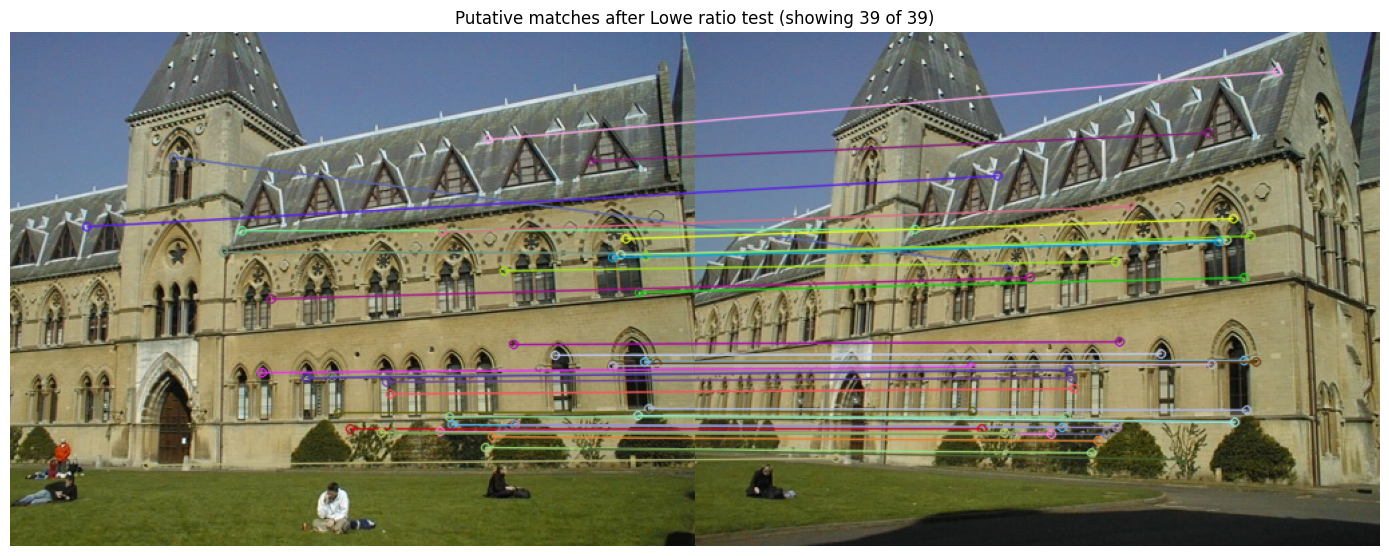

In [8]:
# Visualise putative matches with cv2.drawMatches
def matches_image(img1_rgb, kp1_xy, img2_rgb, kp2_xy, max_draw=80):
    """Side-by-side rendering with colour-coded match lines."""
    a = (img1_rgb * 255).astype(np.uint8)
    b = (img2_rgb * 255).astype(np.uint8)
    kps1 = [cv2.KeyPoint(float(x), float(y), 1.0) for x, y in kp1_xy]
    kps2 = [cv2.KeyPoint(float(x), float(y), 1.0) for x, y in kp2_xy]
    n_draw = min(max_draw, len(kp1_xy))
    sel = np.linspace(0, len(kp1_xy) - 1, n_draw).astype(int)
    dmatches = [cv2.DMatch(int(i), int(i), 0.0) for i in sel]
    out = cv2.drawMatches(a, kps1, b, kps2, dmatches, None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return out


fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.imshow(matches_image(img1_rgb, pts1_put, img2_rgb, pts2_put, max_draw=80))
ax.set_title(f"Putative matches after Lowe ratio test (showing {min(80, len(pts1_put))} of {len(pts1_put)})")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [9]:
def ransac_fundamental(pts1, pts2, iters=RANSAC_ITERS,
                       thresh_px=RANSAC_THRESH_PX, seed=RNG_SEED):
    """RANSAC + normalized 8-point F.

    Inlier metric = Sampson distance < thresh_px.
    Returns (F, inlier_mask, n_inliers).
    """
    rng = np.random.default_rng(seed)
    n = len(pts1)
    if n < 8:
        raise ValueError(f"Need >= 8 putative matches, got {n}")

    best_inliers = np.zeros(n, dtype=bool)
    best_count = 0
    thresh_sq = float(thresh_px) ** 2

    for _ in range(iters):
        sample = rng.choice(n, size=8, replace=False)
        try:
            F_try = estimate_F_normalized_8pt(pts1[sample], pts2[sample])
        except np.linalg.LinAlgError:
            continue
        d = sampson_distance(F_try, pts1, pts2)
        inliers = d < thresh_sq
        count = int(inliers.sum())
        if count > best_count:
            best_count = count
            best_inliers = inliers

    if best_count < 8:
        raise RuntimeError(f"RANSAC failed: best_count={best_count}")

    # Re-fit on full inlier set with normalized 8-point
    F_refined = estimate_F_normalized_8pt(pts1[best_inliers], pts2[best_inliers])
    return F_refined, best_inliers, best_count


F_ransac, inlier_mask, n_inliers = ransac_fundamental(pts1_put, pts2_put)
pts1_in = pts1_put[inlier_mask]
pts2_in = pts2_put[inlier_mask]

residual_step3 = epipolar_residual_img2(F_ransac, pts1_in, pts2_in)
logging.info("RANSAC inliers    : %d / %d  (%.1f%%)",
             n_inliers, len(pts1_put), 100.0 * n_inliers / len(pts1_put))
logging.info("F (RANSAC) =\n%s", F_ransac)
logging.info("Step 3 residual (img2 epipolar, inliers only): %.6f px^2",
             residual_step3)


RANSAC inliers    : 32 / 39  (82.1%)
F (RANSAC) =
[[ 8.00921893e-07  3.89563949e-05 -1.12019233e-02]
 [-1.94770614e-05  3.37335325e-06 -1.44989336e-02]
 [ 5.70651983e-03  9.77442784e-03  1.00000000e+00]]
Step 3 residual (img2 epipolar, inliers only): 0.317740 px^2


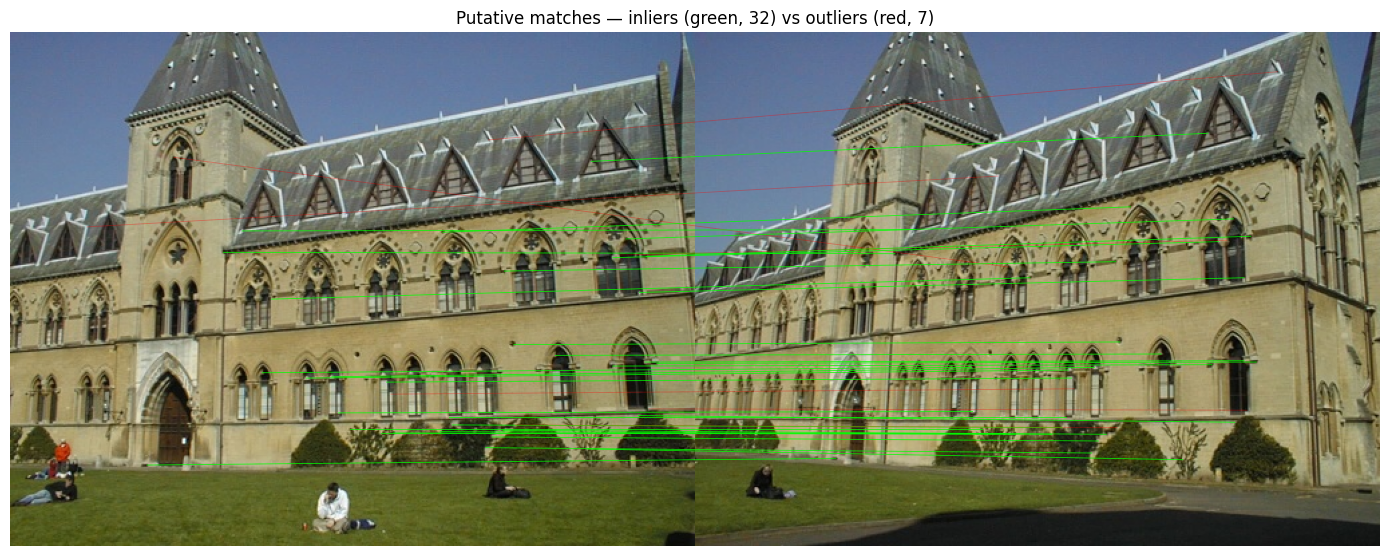

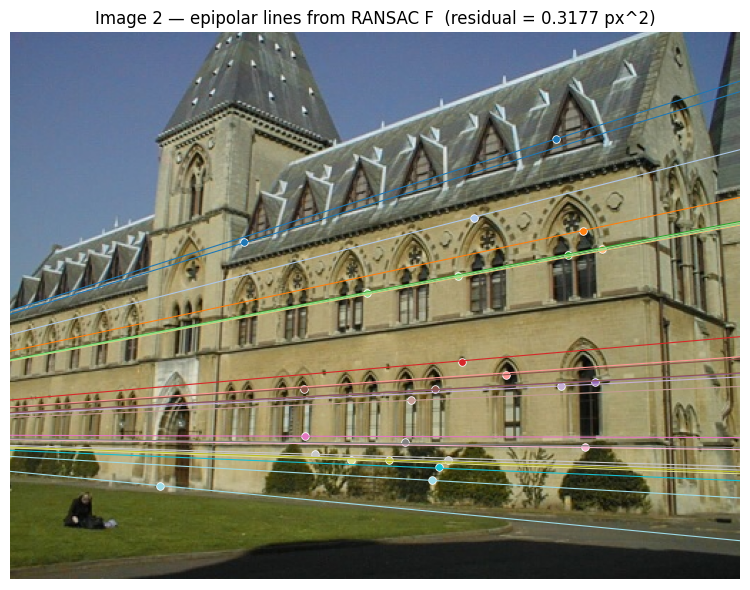

In [10]:
# Visualise inliers (green) vs outliers (red), and a sample of epipolar lines.
def draw_inlier_outlier(img1_rgb, img2_rgb, pts1, pts2, mask):
    h1, w1 = img1_rgb.shape[:2]
    h2, w2 = img2_rgb.shape[:2]
    H = max(h1, h2)
    canvas = np.ones((H, w1 + w2, 3))
    canvas[:h1, :w1] = img1_rgb
    canvas[:h2, w1:w1 + w2] = img2_rgb
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    ax.imshow(canvas)
    for (x1, y1), (x2, y2), is_in in zip(pts1, pts2, mask):
        color = "lime" if is_in else "red"
        alpha = 0.85 if is_in else 0.35
        ax.plot([x1, x2 + w1], [y1, y2], color=color, linewidth=0.6, alpha=alpha)
    ax.set_title(f"Putative matches — inliers (green, {mask.sum()}) vs outliers (red, {(~mask).sum()})")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


draw_inlier_outlier(img1_rgb, img2_rgb, pts1_put, pts2_put, inlier_mask)


# Sample of epipolar lines in image 2 from RANSAC F, on inliers only.
p1_in_h = np.hstack([pts1_in, np.ones((len(pts1_in), 1))])
lines2_r = (F_ransac @ p1_in_h.T).T

sample_idx_in = np.linspace(0, len(pts1_in) - 1, min(N_LINES_VIZ, len(pts1_in))).astype(int)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
draw_epipolar_lines(ax, img2_rgb, lines2_r, pts2_in, sample_idx_in,
                    f"Image 2 — epipolar lines from RANSAC F  (residual = {residual_step3:.4f} px^2)")
plt.tight_layout()
plt.show()


# Step 4: Camera Centers, Linear-LS Triangulation, and 3D Visualization (Ground-Truth Matches)

The two camera matrices `P1`, `P2` are 3×4 — `P = K[R | t]` decomposes into intrinsics, world→camera rotation, and translation. The **camera center** in world coordinates is the right null space of `P` (the point that projects to the origin); equivalently, `C = -R^{-1} K^{-1} (last column of P)`.

For each match `(p1, p2)`, **linear least-squares triangulation (DLT)** stacks the four constraints `[p × (P X)] = 0` into a 4×4 matrix and takes the right null vector — yielding a 3D world point `X` whose projections best fit both observations. We then compute the **reprojection residual** `||p − π(P X)||²` per image.

The 3D figure is **interactive (Plotly WebGL)**: drag to rotate, scroll to zoom, shift-drag to pan, double-click to reset, and click a legend entry to toggle a layer (cameras, frustums, image planes, rays, points). It embeds both **images as textured planes** at their respective camera image planes (positioned at a small depth in front of each camera so the geometry is honest), draws the **camera frustum pyramids**, and overlays a sample of **back-projection rays** from each camera center through the 3D points. By construction, every ray pierces the corresponding pixel on the textured image plane — a built-in visual sanity check on the triangulation. Hovering a 3D point shows its match index, both 2D pixel coordinates, and 3D world coordinate.

In [11]:
# ---------------------------------------------------------------------------
# Camera-geometry helpers
# ---------------------------------------------------------------------------
def camera_center(P):
    """Camera center in world coordinates: right null space of P."""
    _, _, Vt = np.linalg.svd(P)
    C = Vt[-1]
    return C[:3] / C[3]


def decompose_P(P):
    """Decompose P = K[R|t] using OpenCV (handles sign conventions cleanly).

    Returns (K, R, C) where C is the camera center in world coords.
    """
    K, R, t_h, *_ = cv2.decomposeProjectionMatrix(P)
    C = (t_h[:3] / t_h[3]).flatten()
    return K, R, C


def triangulate_linear(P1, P2, pts1, pts2):
    """Linear DLT triangulation for N point pairs.

    Returns (N, 3) world coordinates.
    """
    n = len(pts1)
    X = np.empty((n, 3), dtype=np.float64)
    for i in range(n):
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]
        A = np.vstack([
            x1 * P1[2] - P1[0],
            y1 * P1[2] - P1[1],
            x2 * P2[2] - P2[0],
            y2 * P2[2] - P2[1],
        ])
        _, _, Vt = np.linalg.svd(A)
        Xh = Vt[-1]
        X[i] = Xh[:3] / Xh[3]
    return X


def project(P, X):
    """Project (N,3) world points by P, returning (N,2) pixel coords."""
    Xh = np.hstack([X, np.ones((len(X), 1))])
    xh = (P @ Xh.T).T
    return xh[:, :2] / xh[:, 2:3]


def per_match_pixel_error(P, X, pts):
    """Per-match Euclidean pixel error (N,) — robust statistic input."""
    return np.sqrt(((project(P, X) - pts) ** 2).sum(axis=1))


def reprojection_residual(P, X, pts):
    """Mean squared pixel reprojection error (matches PDF wording)."""
    return float((per_match_pixel_error(P, X, pts) ** 2).mean())


def reprojection_median_px(P, X, pts):
    """Robust median per-match pixel error — outlier-resistant complement."""
    return float(np.median(per_match_pixel_error(P, X, pts)))


# ---------------------------------------------------------------------------
# Compute centers, triangulate GT matches, evaluate residuals
# ---------------------------------------------------------------------------
C1 = camera_center(P1)
C2 = camera_center(P2)
K1, R1, C1_dec = decompose_P(P1)
K2, R2, C2_dec = decompose_P(P2)

logging.info("Camera 1 center (SVD)   : %s", C1)
logging.info("Camera 1 center (decomp): %s", C1_dec)
logging.info("Camera 2 center (SVD)   : %s", C2)
logging.info("Camera 2 center (decomp): %s", C2_dec)
logging.info("Baseline ||C2 - C1||    : %.4f world units", np.linalg.norm(C2 - C1))

X_gt = triangulate_linear(P1, P2, pts1_gt, pts2_gt)
residual_step4_img1 = reprojection_residual(P1, X_gt, pts1_gt)
residual_step4_img2 = reprojection_residual(P2, X_gt, pts2_gt)
median_step4_img1   = reprojection_median_px(P1, X_gt, pts1_gt)
median_step4_img2   = reprojection_median_px(P2, X_gt, pts2_gt)

logging.info("Step 4 reprojection residual img1: %.6f px^2  (median %.4f px)",
             residual_step4_img1, median_step4_img1)
logging.info("Step 4 reprojection residual img2: %.6f px^2  (median %.4f px)",
             residual_step4_img2, median_step4_img2)


Camera 1 center (SVD)   : [  7.28863053 -21.52118112  17.73503585]
Camera 1 center (decomp): [  7.28863053 -21.52118112  17.73503585]
Camera 2 center (SVD)   : [  6.89405488 -15.39232716  23.41498687]
Camera 2 center (decomp): [  6.89405488 -15.39232716  23.41498687]
Baseline ||C2 - C1||    : 8.3654 world units
Step 4 reprojection residual img1: 0.012090 px^2  (median 0.0565 px)
Step 4 reprojection residual img2: 0.016065 px^2  (median 0.0677 px)


In [12]:
# ---------------------------------------------------------------------------
# Interactive 3D visualisation with Plotly
#   - drag    = rotate
#   - scroll  = zoom
#   - shift+drag = pan
#   - double-click = reset view
# ---------------------------------------------------------------------------
def pixel_to_world_ray(P, K, R, C, pixel_xy):
    """World-space unit direction of the ray from C through image pixel (x, y)."""
    p_h = np.array([pixel_xy[0], pixel_xy[1], 1.0])
    d_cam = np.linalg.inv(K) @ p_h          # camera-frame ray
    d_world = R.T @ d_cam                   # world-frame ray (camera->world is R^T)
    return d_world / np.linalg.norm(d_world)


def image_plane_corners(P, K, R, C, img_shape, depth):
    """Return the four image-plane corners in world coords, at distance `depth`."""
    h, w = img_shape[:2]
    principal = R.T @ np.array([0.0, 0.0, 1.0])
    corners_px = [(0, 0), (w - 1, 0), (w - 1, h - 1), (0, h - 1)]
    out = np.empty((4, 3))
    for k, px in enumerate(corners_px):
        d = pixel_to_world_ray(P, K, R, C, px)
        s = depth / max(d @ principal, 1e-9)
        out[k] = C + s * d
    return out


def frustum_lines_trace(C, corners_w, color, name):
    """Plotly Scatter3d 'lines' trace for a camera frustum (4 edges from C + image rectangle)."""
    xs, ys, zs = [], [], []
    # Edges from C to each corner (None separates segments)
    for cw in corners_w:
        xs += [C[0], cw[0], None]
        ys += [C[1], cw[1], None]
        zs += [C[2], cw[2], None]
    # Image-plane rectangle
    rect = np.vstack([corners_w, corners_w[:1]])
    xs += list(rect[:, 0]) + [None]
    ys += list(rect[:, 1]) + [None]
    zs += list(rect[:, 2]) + [None]
    return go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="lines",
        line=dict(color=color, width=3),
        name=name,
        hoverinfo="skip",
        showlegend=False,
    )


def image_plane_mesh(P, K, R, C, img_rgb, depth, stride=IMG_PLANE_STRIDE, name="image"):
    """Plotly Mesh3d that renders `img_rgb` as a textured rectangle at `depth` from C."""
    h, w = img_rgb.shape[:2]
    xs = np.arange(0, w, stride)
    ys = np.arange(0, h, stride)
    if xs[-1] != w - 1:
        xs = np.append(xs, w - 1)
    if ys[-1] != h - 1:
        ys = np.append(ys, h - 1)

    nx, ny = len(xs), len(ys)
    principal = R.T @ np.array([0.0, 0.0, 1.0])

    # Vertex 3D positions: lift each grid pixel along its world-space ray.
    verts = np.empty((ny, nx, 3))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            d = pixel_to_world_ray(P, K, R, C, (x, y))
            s = depth / max(d @ principal, 1e-9)
            verts[i, j] = C + s * d

    # Per-vertex RGB colors sampled from the source image.
    colors = (img_rgb[ys[:, None], xs[None, :]] * 255).clip(0, 255).astype(int)
    vertex_color = [f"rgb({r},{g},{b})" for r, g, b in colors.reshape(-1, 3)]

    # Two triangles per quad.
    tri_i, tri_j, tri_k = [], [], []
    for i in range(ny - 1):
        for j in range(nx - 1):
            v00 = i * nx + j
            v01 = i * nx + (j + 1)
            v10 = (i + 1) * nx + j
            v11 = (i + 1) * nx + (j + 1)
            tri_i += [v00, v00]
            tri_j += [v10, v11]
            tri_k += [v11, v01]

    flat = verts.reshape(-1, 3)
    return go.Mesh3d(
        x=flat[:, 0], y=flat[:, 1], z=flat[:, 2],
        i=tri_i, j=tri_j, k=tri_k,
        vertexcolor=vertex_color,
        flatshading=False,
        lighting=dict(ambient=1.0, diffuse=0.0, specular=0.0),
        lightposition=dict(x=0, y=0, z=10000),
        name=name,
        hoverinfo="skip",
        showlegend=False,
    )


def back_projection_rays_trace(C, X_world, sample_idx, color, name):
    """Plotly trace drawing rays from camera center C through each sampled 3D point."""
    xs, ys, zs = [], [], []
    for i in sample_idx:
        xs += [C[0], X_world[i, 0], None]
        ys += [C[1], X_world[i, 1], None]
        zs += [C[2], X_world[i, 2], None]
    return go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="lines",
        line=dict(color=color, width=1),
        opacity=0.35,
        name=name,
        hoverinfo="skip",
        showlegend=False,
    )


def render_3d_scene(X_world, pts1, pts2, title, ray_stride=RAY_STRIDE):
    """Build an interactive Plotly figure: cameras + image planes + 3D points + rays."""
    # Image planes positioned at ~1/3 of the mean scene distance from each camera.
    centroid = X_world.mean(axis=0)
    scene_depth = max(np.linalg.norm(centroid - C1), np.linalg.norm(centroid - C2))
    plane_depth = scene_depth / 3.0

    corners1 = image_plane_corners(P1, K1, R1, C1, img1_rgb.shape, plane_depth)
    corners2 = image_plane_corners(P2, K2, R2, C2, img2_rgb.shape, plane_depth)

    traces = []

    # Image-plane textures (Mesh3d with per-vertex colors)
    traces.append(image_plane_mesh(P1, K1, R1, C1, img1_rgb, plane_depth, name="img1 plane"))
    traces.append(image_plane_mesh(P2, K2, R2, C2, img2_rgb, plane_depth, name="img2 plane"))

    # Camera frustum line cages
    traces.append(frustum_lines_trace(C1, corners1, "royalblue",   "Camera 1 frustum"))
    traces.append(frustum_lines_trace(C2, corners2, "darkorange",  "Camera 2 frustum"))

    # Camera centers as labelled markers
    traces.append(go.Scatter3d(
        x=[C1[0]], y=[C1[1]], z=[C1[2]],
        mode="markers+text",
        marker=dict(size=6, color="royalblue"),
        text=["C1"], textposition="top center",
        name="Camera 1 center",
    ))
    traces.append(go.Scatter3d(
        x=[C2[0]], y=[C2[1]], z=[C2[2]],
        mode="markers+text",
        marker=dict(size=6, color="darkorange"),
        text=["C2"], textposition="top center",
        name="Camera 2 center",
    ))

    # Back-projection rays from each camera through a sample of 3D points
    n = len(X_world)
    sample_idx = np.arange(0, n, max(1, ray_stride))
    traces.append(back_projection_rays_trace(C1, X_world, sample_idx, "royalblue",  "C1 rays"))
    traces.append(back_projection_rays_trace(C2, X_world, sample_idx, "darkorange", "C2 rays"))

    # Triangulated 3D scene points (hover shows match index + 2D pixels in both images)
    hover_text = [
        f"match #{i}<br>img1=({pts1[i, 0]:.1f}, {pts1[i, 1]:.1f})"
        f"<br>img2=({pts2[i, 0]:.1f}, {pts2[i, 1]:.1f})"
        f"<br>X=({X_world[i, 0]:.2f}, {X_world[i, 1]:.2f}, {X_world[i, 2]:.2f})"
        for i in range(n)
    ]
    traces.append(go.Scatter3d(
        x=X_world[:, 0], y=X_world[:, 1], z=X_world[:, 2],
        mode="markers",
        marker=dict(
            size=4,
            color=np.arange(n),
            colorscale="Viridis",
            showscale=False,
            opacity=0.95,
        ),
        text=hover_text,
        hoverinfo="text",
        name="3D scene points",
    ))

    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        height=720,
        margin=dict(l=0, r=0, t=40, b=0),
        scene=dict(
            xaxis_title="X (world)",
            yaxis_title="Y (world)",
            zaxis_title="Z (world)",
            aspectmode="data",         # honest 1:1:1 world-space scaling
            camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        ),
        legend=dict(itemsizing="constant"),
    )
    fig.show()
    return fig


fig_step4 = render_3d_scene(
    X_gt, pts1_gt, pts2_gt,
    title=f"Step 4 — GT triangulation ({len(X_gt)} points). Drag to rotate, scroll to zoom.",
)


# Step 5: Triangulation Applied to Step 3 RANSAC Inliers

Re-run the same Step-4 machinery on the inlier subset returned by Step 3's RANSAC. Reprojection residuals here use the **original 2D match coordinates** (`pts1_in`, `pts2_in`), not anything derived from `F_ransac` — we want to see how cleanly the *cameras* explain the *putative* matches that survived RANSAC.

In [13]:
X_in = triangulate_linear(P1, P2, pts1_in, pts2_in)
residual_step5_img1 = reprojection_residual(P1, X_in, pts1_in)
residual_step5_img2 = reprojection_residual(P2, X_in, pts2_in)
median_step5_img1   = reprojection_median_px(P1, X_in, pts1_in)
median_step5_img2   = reprojection_median_px(P2, X_in, pts2_in)

logging.info("Step 5 triangulated points : %d", len(X_in))
logging.info("Step 5 reprojection residual img1: %.6f px^2  (median %.4f px)",
             residual_step5_img1, median_step5_img1)
logging.info("Step 5 reprojection residual img2: %.6f px^2  (median %.4f px)",
             residual_step5_img2, median_step5_img2)

fig_step5 = render_3d_scene(
    X_in, pts1_in, pts2_in,
    title=f"Step 5 — RANSAC-inlier triangulation ({len(X_in)} points). Drag to rotate, scroll to zoom.",
)


Step 5 triangulated points : 32
Step 5 reprojection residual img1: 2.888333 px^2  (median 0.2329 px)
Step 5 reprojection residual img2: 3.559956 px^2  (median 0.2733 px)


# Summary of Residuals

This table is built **programmatically from the live variables** above. Edit a parameter (e.g. `LOWE_RATIO`, `RANSAC_THRESH_PX`) and re-run the affected steps — the corresponding row(s) will refresh on the next run of this cell, with no manual edits required.

In [14]:
summary = pd.DataFrame([
    {
        "Step": "Step 2: F from GT matches",
        "Method": "Normalized 8-point (no RANSAC)",
        "N points": len(pts1_gt),
        "img2 epipolar (px^2)": residual_step2,
        "Reproj img1 mean (px^2)": np.nan,
        "Reproj img2 mean (px^2)": np.nan,
        "Reproj img1 median (px)": np.nan,
        "Reproj img2 median (px)": np.nan,
    },
    {
        "Step": "Step 3: F from PA2 putative matches",
        "Method": f"Harris+patch + Norm-8pt + RANSAC (Lowe={LOWE_RATIO}, thresh={RANSAC_THRESH_PX}px)",
        "N points": int(inlier_mask.sum()),
        "img2 epipolar (px^2)": residual_step3,
        "Reproj img1 mean (px^2)": np.nan,
        "Reproj img2 mean (px^2)": np.nan,
        "Reproj img1 median (px)": np.nan,
        "Reproj img2 median (px)": np.nan,
    },
    {
        "Step": "Step 4: Triangulate GT matches",
        "Method": "Linear-LS DLT",
        "N points": len(pts1_gt),
        "img2 epipolar (px^2)": np.nan,
        "Reproj img1 mean (px^2)": residual_step4_img1,
        "Reproj img2 mean (px^2)": residual_step4_img2,
        "Reproj img1 median (px)": median_step4_img1,
        "Reproj img2 median (px)": median_step4_img2,
    },
    {
        "Step": "Step 5: Triangulate Step 3 inliers",
        "Method": "Linear-LS DLT on Harris+patch RANSAC inliers",
        "N points": len(X_in),
        "img2 epipolar (px^2)": np.nan,
        "Reproj img1 mean (px^2)": residual_step5_img1,
        "Reproj img2 mean (px^2)": residual_step5_img2,
        "Reproj img1 median (px)": median_step5_img1,
        "Reproj img2 median (px)": median_step5_img2,
    },
])

# The mean-of-squares is the spec's residual but is fragile under repeated-feature outliers;
# median pixel error is the robust complement that tells the SIFT story honestly.
fmt = {
    "img2 epipolar (px^2)":     "{:.4f}",
    "Reproj img1 mean (px^2)":  "{:.4f}",
    "Reproj img2 mean (px^2)":  "{:.4f}",
    "Reproj img1 median (px)":  "{:.4f}",
    "Reproj img2 median (px)":  "{:.4f}",
}
try:
    from IPython.display import display
    styled = (summary.style
              .format(fmt, na_rep="—")
              .set_caption("PA3 residuals across all steps (recomputes on rerun). "
                           "Mean-of-squares matches spec wording; median pixel error is the "
                           "robust complement under repeated-feature outliers."))
    display(styled)
except (ImportError, AttributeError):
    pretty = summary.copy()
    for col, spec in fmt.items():
        pretty[col] = pretty[col].map(lambda v, s=spec: "—" if pd.isna(v) else s.format(v))
    print("PA3 residuals across all steps (recomputes on rerun)")
    print("Mean-of-squares = spec wording; median pixel error = robust complement.")
    print(pretty.to_string(index=False))


PA3 residuals across all steps (recomputes on rerun)
Mean-of-squares = spec wording; median pixel error = robust complement.
                               Step                                                     Method  N points img2 epipolar (px^2) Reproj img1 mean (px^2) Reproj img2 mean (px^2) Reproj img1 median (px) Reproj img2 median (px)
          Step 2: F from GT matches                             Normalized 8-point (no RANSAC)       309               0.0603                       —                       —                       —                       —
Step 3: F from PA2 putative matches Harris+patch + Norm-8pt + RANSAC (Lowe=0.85, thresh=1.0px)        32               0.3177                       —                       —                       —                       —
     Step 4: Triangulate GT matches                                              Linear-LS DLT       309                    —                  0.0121                  0.0161                  0.0565            

In summary, the 3D visualization when using the exact matches (provided by `library_matches`) is accurate, due to very low reprojection errors on both image 1 and image 2 (Step 2 and 4). When using the same method from Programming Assignment 2 to get the inlier matched features, the reprojection error, while might be considered low, is still much higher relative to the actual matches. I believe the main reason for this is due to some features of the images that are repetitive e.g. repeating windows, causing the matching to confuse some features with other features.